# Deliverable 3 / Task 3 - Weak Supervision and Geometry-Aware Losses

DeiT configuration as the base model, the already resized Task 1 data (`256_nearest`), and the raw `cloth3d++_subset` metadata/videos to cache 14 projected SMPL joints per preprocessed frame.

1. Full supervision: depth L1.
2. Weak-only: ranking + normal consistency.
3. Geometry-aware: depth L1 + scale-invariant depth + joint multi-task loss.
4. Combined final: depth L1 + ranking + normal + scale-invariant + joint loss.

All outputs are saved under `runs/d3_losses`, and exact completed runs are skipped on rerun.


## 1 - Local Setup


In [1]:
from pathlib import Path
import gc, io, json, os, pickle, random, sys, time

import cv2
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import timm
import imageio.v3 as iio

PROJECT_ROOT = Path.cwd().resolve()
DATA_ROOT = PROJECT_ROOT / 'preprocessed_data' / 'resized_variants' / '256_nearest'
RAW_ROOT = PROJECT_ROOT / 'cloth3d++_subset'
D2_DECISIONS = PROJECT_ROOT / 'runs' / 'd2_deit' / 'd2_stage_decisions.json'

RUNS_ROOT = PROJECT_ROOT / 'runs' / 'd3_losses'
FIG_ROOT = RUNS_ROOT / 'figures'
CKPT_ROOT = RUNS_ROOT / 'checkpoints'
HIST_ROOT = RUNS_ROOT / 'histories'
METRIC_ROOT = RUNS_ROOT / 'metrics'
JOINT_CACHE = RUNS_ROOT / 'joints_2d'

for p in [RUNS_ROOT, FIG_ROOT, CKPT_ROOT, HIST_ROOT, METRIC_ROOT, JOINT_CACHE]:
    p.mkdir(parents=True, exist_ok=True)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
if DEVICE == 'cuda':
    torch.backends.cudnn.benchmark = True
    print(f'Device : {torch.cuda.get_device_name(0)}')
    print(f'CUDA   : {torch.version.cuda}')
else:
    print('Device : CPU')

NUM_WORKERS = 0 if os.name == 'nt' else 2
print(f'timm      : {timm.__version__}')
print(f'Data root : {DATA_ROOT}')
print(f'Raw root  : {RAW_ROOT}')
print(f'Runs root : {RUNS_ROOT}')
assert DATA_ROOT.exists(), DATA_ROOT
assert RAW_ROOT.exists(), RAW_ROOT


c:\Users\Daniel Hess\Documents\Master\OR\Pose_Estimation\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device : NVIDIA GeForce RTX 4070
CUDA   : 12.1
timm      : 1.0.27
Data root : C:\Users\Daniel Hess\Documents\Master\OR\Pose_Estimation\preprocessed_data\resized_variants\256_nearest
Raw root  : C:\Users\Daniel Hess\Documents\Master\OR\Pose_Estimation\cloth3d++_subset
Runs root : C:\Users\Daniel Hess\Documents\Master\OR\Pose_Estimation\runs\d3_losses


## 2 - Splits and Task 2 Baseline


In [2]:
def read_list(path):
    with open(path, 'r', encoding='utf-8') as f:
        return [line.strip() for line in f if line.strip()]


train_list = read_list(DATA_ROOT / 'train.txt')
val_list = read_list(DATA_ROOT / 'validation.txt')
test_list = read_list(DATA_ROOT / 'test.txt')
all_names = train_list + val_list + test_list
print(f'Train: {len(train_list)}  Val: {len(val_list)}  Test: {len(test_list)}')

missing_raw = sorted({n.split('_')[0] for n in all_names if not (RAW_ROOT / n.split('_')[0]).exists()})
print(f'Missing raw sequence folders: {len(missing_raw)}')
assert not missing_raw, missing_raw[:10]

with open(D2_DECISIONS, 'r', encoding='utf-8') as f:
    d2_decisions = json.load(f)
D2_BEST = d2_decisions['best_transfer']
print('Task 2 base:', D2_BEST['label'])
print('Task 2 checkpoint:', D2_BEST['checkpoint'])


Train: 30325  Val: 3283  Test: 2827
Missing raw sequence folders: 0
Task 2 base: deit_p8_bilinear_full_finetune_lr1e-4_bs4
Task 2 checkpoint: C:\Users\Daniel Hess\Documents\Master\OR\Pose_Estimation\runs\d2_deit\checkpoints\model_deit_p8_bilinear_full_finetune_lr1e_4_bs4.pth


## 3 - SMPL Joint Projection Cache


In [3]:
DATAREADER_DIR = PROJECT_ROOT / 'cloth3d' / 'DataReader'
sys.path.insert(0, str(PROJECT_ROOT / 'cloth3d'))
sys.path.insert(0, str(DATAREADER_DIR))

from DataReader.util import loadInfo, proj, zRotMatrix
from DataReader.smpl.smpl_np import SMPLModel

JOINT_IDXS = [1, 2, 4, 5, 7, 8, 12, 15, 16, 17, 18, 19, 20, 21]


class CRLFSafeSMPLModel(SMPLModel):
    def __init__(self, model_path):
        # The starter-kit SMPL files are Python-2 text pickles that may contain CRLF.
        # Normalizing to LF in memory avoids mutating the original files.
        raw = Path(model_path).read_bytes().replace(b'\r\n', b'\n')
        params = pickle.load(io.BytesIO(raw), encoding='latin1')
        self.J_regressor = params['J_regressor']
        self.weights = params['weights']
        self.posedirs = params['posedirs']
        self.v_template = params['v_template']
        self.shapedirs = params['shapedirs']
        self.faces = params['f']
        self.kintree_table = params['kintree_table']
        id_to_col = {self.kintree_table[1, i]: i for i in range(self.kintree_table.shape[1])}
        self.parent = {i: id_to_col[self.kintree_table[0, i]] for i in range(1, self.kintree_table.shape[1])}
        self.pose_shape = [24, 3]
        self.beta_shape = [10]
        self.trans_shape = [3]
        self.pose = np.zeros(self.pose_shape)
        self.beta = np.zeros(self.beta_shape)
        self.trans = np.zeros(self.trans_shape)
        self.verts = None
        self.J = None
        self.R = None
        self.update()


SMPL_MODELS = {
    'f': CRLFSafeSMPLModel(DATAREADER_DIR / 'smpl' / 'model_f.pkl'),
    'm': CRLFSafeSMPLModel(DATAREADER_DIR / 'smpl' / 'model_m.pkl'),
}


def read_info(sample):
    return loadInfo(str(RAW_ROOT / sample / 'info'))


def project_points(P, pts3d):
    ones = np.ones((pts3d.shape[0], 1), dtype=np.float32)
    pts_h = np.concatenate([pts3d, ones], axis=1)
    proj_h = (P @ pts_h.T).T
    w = proj_h[:, 2:3]
    xy = proj_h[:, :2] / (w + 1e-9)
    return xy, w.squeeze(1)


def crop_bounds_from_mask(mask, margin=10):
    if not mask.any():
        return None
    rows = np.any(mask, axis=1)
    cols = np.any(mask, axis=0)
    rmin, rmax = np.where(rows)[0][[0, -1]]
    cmin, cmax = np.where(cols)[0][[0, -1]]
    cy = int((rmin + rmax) / 2)
    cx = int((cmin + cmax) / 2)
    half = max(rmax - rmin, cmax - cmin) // 2 + margin
    H, W = mask.shape[:2]
    return max(0, cx - half), max(0, cy - half), min(W, cx + half), min(H, cy + half)


def build_crop_table(sample, frames):
    segm_path = RAW_ROOT / sample / f'{sample}_segm.mkv'
    needed = set(frames)
    max_frame = max(needed)
    crop_table = {}

    # imageio-ffmpeg handles the CLOTH3D++ MKV codec more reliably on Windows than OpenCV.
    try:
        for frame_idx, seg in enumerate(iio.imiter(segm_path)):
            if frame_idx > max_frame:
                break
            if frame_idx in needed:
                mask = seg[:, :, 0] > 0
                bounds = crop_bounds_from_mask(mask, margin=10)
                if bounds is not None:
                    crop_table[frame_idx] = bounds
        return crop_table
    except Exception as exc:
        print(f'imageio failed for {segm_path.name}: {exc}; trying OpenCV fallback')

    cap = cv2.VideoCapture(str(segm_path))
    if not cap.isOpened():
        raise FileNotFoundError(segm_path)
    frame_idx = 0
    while frame_idx <= max_frame:
        ok, seg = cap.read()
        if not ok:
            break
        if frame_idx in needed:
            mask = seg[:, :, 0] > 0
            bounds = crop_bounds_from_mask(mask, margin=10)
            if bounds is not None:
                crop_table[frame_idx] = bounds
        frame_idx += 1
    cap.release()
    return crop_table


def build_joint_cache(sample_names, img_size=256, limit=None):
    names = sample_names if limit is None else sample_names[:limit]
    sample_map = {}
    for name in names:
        sample, frame = name.split('_')
        sample_map.setdefault(sample, set()).add(int(frame))

    total = len(names)
    cached = 0
    failed = []
    t0 = time.time()

    for sample, frames in sorted(sample_map.items()):
        info = read_info(sample)
        P = proj(info['camLoc'])
        zrot = zRotMatrix(info['zrot'])
        gender = 'm' if info['gender'] else 'f'
        smpl = SMPL_MODELS[gender]
        crop_table = build_crop_table(sample, frames)

        for frame_idx in sorted(frames):
            name = f'{sample}_{frame_idx}'
            out_path = JOINT_CACHE / f'{name}.npz'
            if out_path.exists():
                try:
                    existing = np.load(out_path)
                    if existing['vis'].sum() > 0:
                        cached += 1
                        continue
                except Exception:
                    pass
            try:
                if frame_idx not in crop_table:
                    raise RuntimeError('missing crop')
                pose = info['poses'][:, frame_idx].reshape(smpl.pose_shape)
                shape = info['shape']
                trans = info['trans'][:, frame_idx].reshape(smpl.trans_shape)
                _, joints3d = smpl.set_params(pose=pose, beta=shape, trans=trans)
                joints3d = joints3d - joints3d[0:1]
                joints3d = zrot.dot(joints3d.T).T[JOINT_IDXS]
                xy, z = project_points(P, joints3d)
                x1, y1, x2, y2 = crop_table[frame_idx]
                crop_w = max(1, x2 - x1)
                crop_h = max(1, y2 - y1)
                xy[:, 0] = (xy[:, 0] - x1) * (img_size / crop_w)
                xy[:, 1] = (xy[:, 1] - y1) * (img_size / crop_h)
                vis = (z > 0) & (xy[:, 0] >= 0) & (xy[:, 0] < img_size) & (xy[:, 1] >= 0) & (xy[:, 1] < img_size)
                np.savez(out_path, joints=xy.astype(np.float32), vis=vis.astype(np.uint8))
                cached += 1
            except Exception as exc:
                failed.append((name, str(exc)))
                np.savez(out_path, joints=np.zeros((len(JOINT_IDXS), 2), dtype=np.float32), vis=np.zeros((len(JOINT_IDXS),), dtype=np.uint8))
                cached += 1

        if cached % 1000 == 0 or cached == total:
            print(f'Joint cache: {cached}/{total} ({time.time() - t0:.1f}s)')

    report = {'requested': total, 'cached': cached, 'failed': failed[:200], 'n_failed': len(failed)}
    (RUNS_ROOT / 'joint_cache_report.json').write_text(json.dumps(report, indent=2), encoding='utf-8')
    print(f'Joint cache ready: {cached}/{total}, failed={len(failed)}')
    return report


C:\Users\Daniel Hess\AppData\Local\Temp\ipykernel_4688\3274506829.py:16: DeprecationWarning: Please import `csc_matrix` from the `scipy.sparse` namespace; the `scipy.sparse.csc` namespace is deprecated and will be removed in SciPy 2.0.0.
  params = pickle.load(io.BytesIO(raw), encoding='latin1')


In [4]:
# Smoke-test a tiny cache first, then build the full cache. Existing files are skipped.
smoke_report = build_joint_cache(train_list[:8], img_size=256, limit=8)
print('Smoke joint-cache failures:', smoke_report['n_failed'])
full_joint_report = build_joint_cache(all_names, img_size=256)


Joint cache: 8/8 (0.1s)
Joint cache ready: 8/8, failed=0
Smoke joint-cache failures: 0
Joint cache: 13000/36435 (95.4s)
Joint cache: 36435/36435 (253.2s)
Joint cache ready: 36435/36435, failed=0


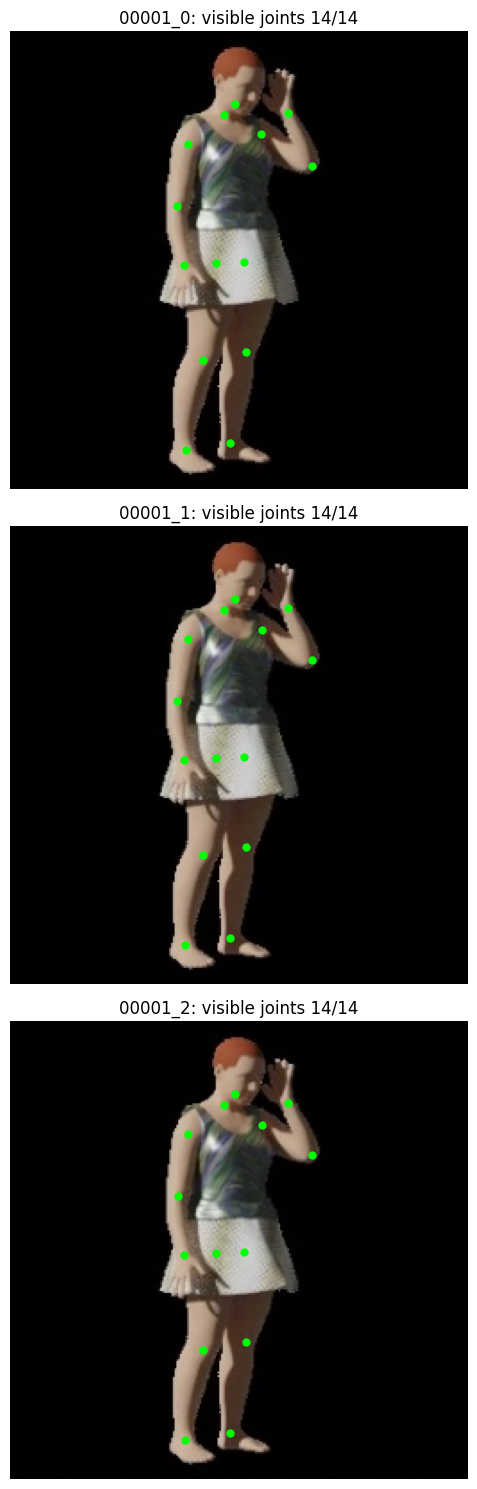

Saved: C:\Users\Daniel Hess\Documents\Master\OR\Pose_Estimation\runs\d3_losses\figures\joint_cache_smoke.png


In [5]:
def visualize_joint_cache(names, n=3):
    fig, axes = plt.subplots(n, 1, figsize=(5, 5 * n))
    if n == 1:
        axes = [axes]
    shown = 0
    for name in names:
        jp = JOINT_CACHE / f'{name}.npz'
        if not jp.exists():
            continue
        data = np.load(jp)
        joints, vis = data['joints'], data['vis'].astype(bool)
        img = cv2.cvtColor(cv2.imread(str(DATA_ROOT / 'image' / f'{name}.jpg')), cv2.COLOR_BGR2RGB)
        ax = axes[shown]
        ax.imshow(img)
        ax.scatter(joints[vis, 0], joints[vis, 1], c='lime', s=25)
        ax.set_title(f'{name}: visible joints {vis.sum()}/{len(vis)}')
        ax.axis('off')
        shown += 1
        if shown >= n:
            break
    plt.tight_layout()
    out = FIG_ROOT / 'joint_cache_smoke.png'
    plt.savefig(out, dpi=150)
    plt.show()
    print(f'Saved: {out}')


visualize_joint_cache(train_list, n=3)


## 4 - Dataset


In [6]:
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGENET_STD = np.array([0.229, 0.224, 0.225], dtype=np.float32)


class Cloth3DDatasetD3(Dataset):
    def __init__(self, data_list, root, joint_cache, img_size=256):
        self.data_list = data_list
        self.root = Path(root)
        self.joint_cache = Path(joint_cache)
        self.img_size = img_size

    def __len__(self):
        return len(self.data_list)

    def __getitem__(self, idx):
        name = self.data_list[idx]
        img = cv2.imread(str(self.root / 'image' / f'{name}.jpg'))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
        dpt = np.load(self.root / 'depth' / f'{name}.npy').astype(np.float32)

        if img.shape[:2] != (self.img_size, self.img_size):
            img = cv2.resize(img, (self.img_size, self.img_size), interpolation=cv2.INTER_LINEAR)
            dpt = cv2.resize(dpt, (self.img_size, self.img_size), interpolation=cv2.INTER_NEAREST)

        mask = dpt > 0
        if mask.any():
            dpt[mask] = (dpt[mask] - dpt[mask].min() + 0.001) / 2.0
        img = (img - IMAGENET_MEAN) / IMAGENET_STD

        joints = np.zeros((len(JOINT_IDXS), 2), dtype=np.float32)
        vis = np.zeros((len(JOINT_IDXS),), dtype=np.uint8)
        jp = self.joint_cache / f'{name}.npz'
        if jp.exists():
            data = np.load(jp)
            joints = data['joints'].astype(np.float32)
            vis = data['vis'].astype(np.uint8)

        return (
            torch.from_numpy(img).permute(2, 0, 1).float(),
            torch.from_numpy(dpt).unsqueeze(0).float(),
            torch.from_numpy(joints).float(),
            torch.from_numpy(vis).float(),
        )


## 5 - Model


In [7]:
class DeiTEncoder(nn.Module):
    def __init__(self, patch_size=8, pretrained=True, img_size=256):
        super().__init__()
        self.backbone = timm.create_model(
            'deit_small_patch16_224',
            pretrained=pretrained,
            img_size=img_size,
            patch_size=patch_size,
            num_classes=0,
        )
        self.out_channels = [self.backbone.embed_dim]

    def forward(self, x):
        feats = self.backbone.forward_features(x)
        patches = feats[:, 1:]
        side = int(patches.shape[1] ** 0.5)
        return [patches.reshape(x.shape[0], side, side, -1).permute(0, 3, 1, 2).contiguous()]


class DepthJointDecoder(nn.Module):
    def __init__(self, in_channels_list, target_size=256, num_joints=14):
        super().__init__()
        self.target_size = target_size
        in_ch = in_channels_list[-1]
        self.trunk = nn.Sequential(
            nn.Conv2d(in_ch, 256, 3, padding=1), nn.BatchNorm2d(256), nn.GELU(),
            nn.Conv2d(256, 128, 3, padding=1), nn.BatchNorm2d(128), nn.GELU(),
            nn.Conv2d(128, 64, 3, padding=1), nn.BatchNorm2d(64), nn.GELU(),
        )
        self.depth_head = nn.Sequential(nn.Conv2d(64, 1, 1), nn.Sigmoid())
        self.joint_head = nn.Conv2d(64, num_joints, 1)

    def forward(self, features):
        x = F.interpolate(features[-1], size=(self.target_size, self.target_size), mode='bilinear', align_corners=False)
        x = self.trunk(x)
        return self.depth_head(x), self.joint_head(x)


class MultiTaskDepthModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.encoder = DeiTEncoder(patch_size=cfg['patch_size'], pretrained=cfg['pretrained'], img_size=cfg['img_size'])
        self.decoder = DepthJointDecoder(self.encoder.out_channels, target_size=cfg['img_size'], num_joints=len(JOINT_IDXS))

    def forward(self, x):
        return self.decoder(self.encoder(x))


def load_d2_weights(model, checkpoint_path):
    if not checkpoint_path or not Path(checkpoint_path).exists():
        print('No compatible D2 checkpoint found; training from ImageNet initialization.')
        return
    state = torch.load(checkpoint_path, map_location='cpu', weights_only=True)
    mapped = {}
    for k, v in state.items():
        if k.startswith('encoder.'):
            mapped[k] = v
        elif k.startswith('decoder.refine.'):
            suffix = k.replace('decoder.refine.', '')
            idx = int(suffix.split('.')[0])
            rest = '.'.join(suffix.split('.')[1:])
            if idx <= 8:
                mapped[f'decoder.trunk.{idx}.{rest}'] = v
            elif idx == 9:
                mapped[f'decoder.depth_head.0.{rest}'] = v
    missing, unexpected = model.load_state_dict(mapped, strict=False)
    print(f'Loaded compatible D2 weights: {len(mapped)} tensors | missing={len(missing)} unexpected={len(unexpected)}')


## 6 - Losses and Metrics


In [8]:
def rmse(pred, gt):
    mask = gt > 0
    if not mask.any():
        return torch.tensor(0.0, device=pred.device)
    return torch.sqrt(F.mse_loss(pred[mask], gt[mask]))


def depth_to_normals(depth, eps=1e-6):
    dz_dx = depth[:, :, :, 2:] - depth[:, :, :, :-2]
    dz_dy = depth[:, :, 2:, :] - depth[:, :, :-2, :]
    dz_dx = F.pad(dz_dx, [1, 1, 0, 0])
    dz_dy = F.pad(dz_dy, [0, 0, 1, 1])
    n = torch.cat([-dz_dx, -dz_dy, torch.ones_like(dz_dx)], dim=1)
    return n / (torch.norm(n, dim=1, keepdim=True) + eps)


def mean_angular_error(pred_depth, gt_depth):
    mask = (gt_depth > 0).squeeze(1)
    n_pred = depth_to_normals(pred_depth)
    n_gt = depth_to_normals(gt_depth)
    angle = torch.acos((n_pred * n_gt).sum(dim=1).clamp(-1.0, 1.0)) * (180.0 / torch.pi)
    return angle[mask].mean() if mask.any() else torch.tensor(0.0, device=pred_depth.device)


def depth_l1_loss(pred, gt):
    mask = gt > 0
    return F.l1_loss(pred[mask], gt[mask]) if mask.any() else torch.tensor(0.0, device=pred.device)


def normal_consistency_loss(pred, gt):
    mask = (gt > 0).squeeze(1)
    if not mask.any():
        return torch.tensor(0.0, device=pred.device)
    n_pred = depth_to_normals(pred)
    n_gt = depth_to_normals(gt)
    return F.l1_loss(n_pred.permute(0, 2, 3, 1)[mask], n_gt.permute(0, 2, 3, 1)[mask])


def scale_invariant_loss(pred, gt, lam=0.5):
    mask = gt > 0
    if not mask.any():
        return torch.tensor(0.0, device=pred.device)
    d = torch.log(pred[mask] + 1e-6) - torch.log(gt[mask] + 1e-6)
    return d.pow(2).mean() - lam * d.mean().pow(2)


def ranking_loss(pred, gt, n_pairs=1024, margin=0.05):
    mask = (gt > 0).squeeze(1)
    pred_flat = pred.squeeze(1).reshape(pred.shape[0], -1)
    gt_flat = gt.squeeze(1).reshape(gt.shape[0], -1)
    mask_flat = mask.reshape(mask.shape[0], -1)
    losses = []
    for b in range(pred.shape[0]):
        valid = torch.where(mask_flat[b])[0]
        if valid.numel() < 2:
            continue
        picks = valid[torch.randint(0, valid.numel(), (n_pairs * 2,), device=pred.device)]
        i1, i2 = picks[:n_pairs], picks[n_pairs:]
        sign = torch.sign(gt_flat[b, i1] - gt_flat[b, i2])
        sign[sign == 0] = 1
        losses.append(F.relu(margin - sign * (pred_flat[b, i1] - pred_flat[b, i2])).mean())
    return torch.stack(losses).mean() if losses else torch.tensor(0.0, device=pred.device)


def soft_argmax_2d(heatmaps, beta=80.0):
    B, J, H, W = heatmaps.shape
    probs = F.softmax(heatmaps.reshape(B, J, -1) * beta, dim=-1)
    ys = torch.linspace(0, H - 1, H, device=heatmaps.device)
    xs = torch.linspace(0, W - 1, W, device=heatmaps.device)
    gy, gx = torch.meshgrid(ys, xs, indexing='ij')
    grid = torch.stack([gx.reshape(-1), gy.reshape(-1)], dim=0).view(1, 1, 2, -1)
    return (probs.unsqueeze(2) * grid).sum(dim=-1)


def joint_l1_loss(pred_xy, gt_xy, vis, img_size=256, normalized=True):
    mask = vis.unsqueeze(-1)
    if mask.sum() < 1:
        return torch.tensor(0.0, device=pred_xy.device)
    loss = (torch.abs(pred_xy - gt_xy) * mask).sum() / mask.sum()
    return loss / img_size if normalized else loss


## 7 - Training and Caching


In [9]:
BASE_CONFIG = {
    'root': DATA_ROOT,
    'img_size': 256,
    'patch_size': int(D2_BEST.get('patch_size', 8)),
    'pretrained': True,
    'd2_checkpoint': D2_BEST.get('checkpoint'),
    'batch_size': int(D2_BEST.get('batch_size', 4)),
    'lr': float(D2_BEST.get('lr', 1e-4)),
    'weight_decay': 1e-4,
    'epochs': 8,
    'seed': 42,
    'rank_pairs': 1024,
    'rank_margin': 0.05,
    'si_lambda': 0.5,
    'resume': True,
}

LOSS_CONFIGS = {
    'full': {'depth_l1': 1.0, 'normal': 0.0, 'rank': 0.0, 'scale_inv': 0.0, 'joint_l1': 0.0},
    'weak': {'depth_l1': 0.0, 'normal': 1.0, 'rank': 1.0, 'scale_inv': 0.0, 'joint_l1': 0.0},
    'geom': {'depth_l1': 1.0, 'normal': 0.0, 'rank': 0.0, 'scale_inv': 0.5, 'joint_l1': 1.0},
    'combined': {'depth_l1': 1.0, 'normal': 0.5, 'rank': 0.2, 'scale_inv': 0.5, 'joint_l1': 1.0},
}


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def slugify(label):
    return ''.join(ch.lower() if ch.isalnum() else '_' for ch in label).strip('_')


def build_cfg(regime):
    cfg = {**BASE_CONFIG, 'regime': regime, 'loss_weights': LOSS_CONFIGS[regime]}
    tag = slugify(f'd3_{regime}_deit_p{cfg["patch_size"]}_bs{cfg["batch_size"]}_lr{cfg["lr"]:.0e}'.replace('+0', '').replace('-0', '-'))
    cfg['label'] = tag
    cfg['checkpoint'] = CKPT_ROOT / f'model_{tag}.pth'
    cfg['latest_checkpoint'] = CKPT_ROOT / f'latest_{tag}.pth'
    cfg['history_path'] = HIST_ROOT / f'hist_{tag}.pkl'
    cfg['result_path'] = METRIC_ROOT / f'result_{tag}.json'
    return cfg


def make_loader(data_list, cfg, shuffle, batch_size=None):
    ds = Cloth3DDatasetD3(data_list, cfg['root'], JOINT_CACHE, cfg['img_size'])
    return DataLoader(ds, batch_size=batch_size or cfg['batch_size'], shuffle=shuffle, num_workers=NUM_WORKERS, pin_memory=(DEVICE == 'cuda'))


def result_from_cfg(cfg, status='ok', **metrics):
    return {
        'label': cfg['label'], 'regime': cfg['regime'], 'status': status,
        'val_rmse': metrics.get('val_rmse', float('inf')),
        'test_rmse': metrics.get('test_rmse', float('inf')),
        'normal_mae': metrics.get('normal_mae', float('inf')),
        'joint_l1_px': metrics.get('joint_l1_px', float('inf')),
        'fps': metrics.get('fps', 0.0),
        'params': metrics.get('params', 0),
        'gpu_mb': metrics.get('gpu_mb', 0.0),
        'patch_size': cfg['patch_size'], 'batch_size': cfg['batch_size'], 'lr': cfg['lr'],
        'loss_weights': cfg['loss_weights'],
        'checkpoint': str(cfg['checkpoint']), 'history_path': str(cfg['history_path']), 'result_path': str(cfg['result_path']),
    }


def save_result(result):
    Path(result['result_path']).write_text(json.dumps(result, indent=2), encoding='utf-8')
    return result


def load_cached_result(cfg):
    if cfg['result_path'].exists():
        print(f'Found saved metrics: {cfg["result_path"].name}; skipping training.')
        return json.loads(cfg['result_path'].read_text(encoding='utf-8'))
    return None


def cleanup_cuda():
    gc.collect()
    if DEVICE == 'cuda':
        torch.cuda.empty_cache()


In [10]:
def compute_losses(pred_depth, pred_heat, Y, J, V, cfg):
    pred_xy = soft_argmax_2d(pred_heat)
    parts = {
        'depth_l1': depth_l1_loss(pred_depth, Y),
        'normal': normal_consistency_loss(pred_depth, Y),
        'rank': ranking_loss(pred_depth, Y, cfg['rank_pairs'], cfg['rank_margin']),
        'scale_inv': scale_invariant_loss(pred_depth, Y, cfg['si_lambda']),
        'joint_l1': joint_l1_loss(pred_xy, J, V, cfg['img_size'], normalized=True),
    }
    total = sum(cfg['loss_weights'][k] * parts[k] for k in cfg['loss_weights'])
    parts['total'] = total
    return parts


def train_epoch(model, loader, optimizer, cfg):
    model.train()
    totals = {k: 0.0 for k in ['total', 'depth_l1', 'normal', 'rank', 'scale_inv', 'joint_l1']}
    for X, Y, J, V in loader:
        X, Y, J, V = X.to(DEVICE, non_blocking=True), Y.to(DEVICE, non_blocking=True), J.to(DEVICE, non_blocking=True), V.to(DEVICE, non_blocking=True)
        pred_depth, pred_heat = model(X)
        losses = compute_losses(pred_depth, pred_heat, Y, J, V, cfg)
        optimizer.zero_grad(set_to_none=True)
        losses['total'].backward()
        optimizer.step()
        for k in totals:
            totals[k] += losses[k].item()
    return {k: v / max(1, len(loader)) for k, v in totals.items()}


@torch.no_grad()
def val_epoch(model, loader, cfg):
    model.eval()
    total_rmse, total_mae, total_joint, n = 0.0, 0.0, 0.0, 0
    for X, Y, J, V in loader:
        X, Y, J, V = X.to(DEVICE, non_blocking=True), Y.to(DEVICE, non_blocking=True), J.to(DEVICE, non_blocking=True), V.to(DEVICE, non_blocking=True)
        pred_depth, pred_heat = model(X)
        pred_xy = soft_argmax_2d(pred_heat)
        total_rmse += rmse(pred_depth, Y).item()
        total_mae += mean_angular_error(pred_depth, Y).item()
        total_joint += joint_l1_loss(pred_xy, J, V, cfg['img_size'], normalized=False).item()
        n += 1
    return total_rmse / max(1, n), total_mae / max(1, n), total_joint / max(1, n)


def save_latest(path, model, optimizer, scheduler, epoch, best_rmse, history):
    torch.save({'epoch': epoch, 'model': model.state_dict(), 'optimizer': optimizer.state_dict(), 'scheduler': scheduler.state_dict(), 'best_rmse': best_rmse, 'history': history}, path)


def train(model, cfg):
    train_dl = make_loader(train_list, cfg, shuffle=True)
    val_dl = make_loader(val_list, cfg, shuffle=False)
    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg['lr'], weight_decay=cfg['weight_decay'])
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg['epochs'])
    history = {k: [] for k in ['train_total', 'train_depth_l1', 'train_normal', 'train_rank', 'train_scale_inv', 'train_joint_l1', 'val_rmse', 'val_mae_n', 'val_joint_l1_px', 'epoch_seconds']}
    best_rmse, start_epoch = float('inf'), 0

    if cfg['latest_checkpoint'].exists() and cfg.get('resume', True):
        print(f'Resuming from {cfg["latest_checkpoint"]}')
        ckpt = torch.load(cfg['latest_checkpoint'], map_location=DEVICE, weights_only=False)
        model.load_state_dict(ckpt['model'])
        optimizer.load_state_dict(ckpt['optimizer'])
        scheduler.load_state_dict(ckpt['scheduler'])
        start_epoch = ckpt['epoch'] + 1
        best_rmse = ckpt['best_rmse']
        history = ckpt['history']

    for epoch in range(start_epoch, cfg['epochs']):
        t0 = time.time()
        tr = train_epoch(model, train_dl, optimizer, cfg)
        v_rmse, v_mae, v_joint = val_epoch(model, val_dl, cfg)
        scheduler.step()
        elapsed = time.time() - t0
        for k in ['total', 'depth_l1', 'normal', 'rank', 'scale_inv', 'joint_l1']:
            history[f'train_{k}'].append(tr[k])
        history['val_rmse'].append(v_rmse)
        history['val_mae_n'].append(v_mae)
        history['val_joint_l1_px'].append(v_joint)
        history['epoch_seconds'].append(elapsed)
        print(f'[{cfg["regime"]}] Epoch {epoch+1:02d}/{cfg["epochs"]} | loss={tr["total"]:.4f} | val_RMSE={v_rmse:.4f} | val_NormalMAE={v_mae:.2f} | val_JointL1px={v_joint:.2f} | {elapsed:.1f}s')
        if v_rmse < best_rmse:
            best_rmse = v_rmse
            torch.save(model.state_dict(), cfg['checkpoint'])
        save_latest(cfg['latest_checkpoint'], model, optimizer, scheduler, epoch, best_rmse, history)

    with open(cfg['history_path'], 'wb') as fh:
        pickle.dump(history, fh)
    print(f'Best val RMSE: {best_rmse:.4f}')
    return history, best_rmse


@torch.no_grad()
def evaluate(model, cfg):
    model.eval()
    model.load_state_dict(torch.load(cfg['checkpoint'], map_location=DEVICE, weights_only=True))
    dl = make_loader(test_list, cfg, shuffle=False, batch_size=1)
    if DEVICE == 'cuda':
        torch.cuda.reset_peak_memory_stats()
    total_rmse, total_mae, total_joint, times = 0.0, 0.0, 0.0, []
    for X, Y, J, V in dl:
        X, Y, J, V = X.to(DEVICE), Y.to(DEVICE), J.to(DEVICE), V.to(DEVICE)
        if DEVICE == 'cuda':
            torch.cuda.synchronize()
        t0 = time.time()
        pred_depth, pred_heat = model(X)
        if DEVICE == 'cuda':
            torch.cuda.synchronize()
        times.append(time.time() - t0)
        pred_xy = soft_argmax_2d(pred_heat)
        total_rmse += rmse(pred_depth, Y).item()
        total_mae += mean_angular_error(pred_depth, Y).item()
        total_joint += joint_l1_loss(pred_xy, J, V, cfg['img_size'], normalized=False).item()
    n = len(dl)
    result = result_from_cfg(cfg, test_rmse=total_rmse / n, normal_mae=total_mae / n, joint_l1_px=total_joint / n, fps=1.0 / (sum(times) / len(times)), params=sum(p.numel() for p in model.parameters()), gpu_mb=torch.cuda.max_memory_allocated() / 1024**2 if DEVICE == 'cuda' else 0.0)
    print('=' * 72)
    print(cfg['label'])
    print(f'  Test RMSE         : {result["test_rmse"]:.4f}')
    print(f'  Normal MAE        : {result["normal_mae"]:.2f} deg')
    print(f'  Joint L1 px       : {result["joint_l1_px"]:.2f}')
    print(f'  FPS               : {result["fps"]:.1f}')
    print(f'  Peak GPU mem (MB) : {result["gpu_mb"]:.1f}')
    print('=' * 72)
    return result


In [11]:
results = []


def append_and_save(result):
    existing = {r['label']: r for r in results}
    existing[result['label']] = result
    results.clear()
    results.extend(existing.values())
    pd.DataFrame(results).to_csv(RUNS_ROOT / 'd3_results_so_far.csv', index=False)


def run_regime(regime):
    cfg = build_cfg(regime)
    print('\n' + '#' * 72)
    print(f'RUN: {cfg["label"]}')
    print('#' * 72)
    cached = load_cached_result(cfg)
    if cached is not None:
        append_and_save(cached)
        return cached
    try:
        set_seed(cfg['seed'])
        model = MultiTaskDepthModel(cfg).to(DEVICE)
        load_d2_weights(model, cfg['d2_checkpoint'])
        history, best_val_rmse = train(model, cfg)
        result = evaluate(model, cfg)
        result['val_rmse'] = best_val_rmse
        result = save_result(result)
    except RuntimeError as exc:
        if 'out of memory' in str(exc).lower():
            print(f'OOM during {cfg["label"]}; recording failed run.')
            result = save_result(result_from_cfg(cfg, status='failed_oom'))
        else:
            raise
    finally:
        cleanup_cuda()
    append_and_save(result)
    return result


def summarize_results(title, group_results):
    cols = ['regime', 'status', 'val_rmse', 'test_rmse', 'normal_mae', 'joint_l1_px', 'fps', 'gpu_mb']
    df_group = pd.DataFrame(group_results)[cols].sort_values(['status', 'val_rmse']).reset_index(drop=True)
    print('\n' + '=' * 72)
    print(title)
    print('=' * 72)
    print(df_group.to_string(index=False))
    ok = [r for r in group_results if r['status'] == 'ok']
    best = min(ok, key=lambda r: (r['val_rmse'], r['normal_mae'], r['joint_l1_px']))
    print(f'\nDecision: {best["regime"]} selected by validation RMSE first, then normal MAE and joint L1.')
    return best, df_group


## 8 - Smoke Test


In [12]:
RUN_SMOKE_TEST = False

if RUN_SMOKE_TEST:
    old_train, old_val, old_epochs = train_list, val_list, BASE_CONFIG['epochs']
    train_list = old_train[:16]
    val_list = old_val[:8]
    BASE_CONFIG['epochs'] = 1
    smoke = run_regime('full')
    BASE_CONFIG['epochs'] = old_epochs
    train_list = old_train
    val_list = old_val
    print('Smoke result:', smoke)
else:
    print('Smoke test disabled. Set RUN_SMOKE_TEST=True to run a tiny 1-epoch check.')


Smoke test disabled. Set RUN_SMOKE_TEST=True to run a tiny 1-epoch check.


## 9 - Run Loss Regimes


In [13]:
regime_results = [
    run_regime('full'),
    run_regime('weak'),
    run_regime('geom'),
    run_regime('combined'),
]
best_regime, regime_table = summarize_results('Task 3 regime comparison', regime_results)

STAGE_DECISIONS = {'best_regime': best_regime, 'all_regimes': regime_results}
(RUNS_ROOT / 'd3_stage_decisions.json').write_text(json.dumps(STAGE_DECISIONS, indent=2), encoding='utf-8')



########################################################################
RUN: d3_full_deit_p8_bs4_lr1e_4
########################################################################
Loaded compatible D2 weights: 173 tensors | missing=2 unexpected=0
[full] Epoch 01/8 | loss=0.0147 | val_RMSE=0.0733 | val_NormalMAE=1.51 | val_JointL1px=139.87 | 1937.1s
[full] Epoch 02/8 | loss=0.0127 | val_RMSE=0.0730 | val_NormalMAE=1.51 | val_JointL1px=164.09 | 1852.8s
[full] Epoch 03/8 | loss=0.0108 | val_RMSE=0.0708 | val_NormalMAE=1.51 | val_JointL1px=175.26 | 1853.6s
[full] Epoch 04/8 | loss=0.0090 | val_RMSE=0.0699 | val_NormalMAE=1.52 | val_JointL1px=167.27 | 1853.3s
[full] Epoch 05/8 | loss=0.0074 | val_RMSE=0.0699 | val_NormalMAE=1.51 | val_JointL1px=168.18 | 1852.1s
[full] Epoch 06/8 | loss=0.0060 | val_RMSE=0.0695 | val_NormalMAE=1.51 | val_JointL1px=163.13 | 1852.2s
[full] Epoch 07/8 | loss=0.0050 | val_RMSE=0.0695 | val_NormalMAE=1.51 | val_JointL1px=173.06 | 1851.6s
[full] Epoch 08/8 | loss=0

Loaded compatible D2 weights: 173 tensors | missing=2 unexpected=0
[weak] Epoch 01/8 | loss=0.0189 | val_RMSE=0.0993 | val_NormalMAE=1.34 | val_JointL1px=175.73 | 1841.9s
[weak] Epoch 02/8 | loss=0.0174 | val_RMSE=0.1102 | val_NormalMAE=1.34 | val_JointL1px=175.99 | 1840.2s
[weak] Epoch 03/8 | loss=0.0165 | val_RMSE=0.1170 | val_NormalMAE=1.34 | val_JointL1px=190.67 | 1840.6s
[weak] Epoch 04/8 | loss=0.0158 | val_RMSE=0.1270 | val_NormalMAE=1.35 | val_JointL1px=182.21 | 1841.2s
[weak] Epoch 05/8 | loss=0.0152 | val_RMSE=0.1287 | val_NormalMAE=1.33 | val_JointL1px=175.80 | 1841.4s
[weak] Epoch 06/8 | loss=0.0147 | val_RMSE=0.1345 | val_NormalMAE=1.35 | val_JointL1px=171.91 | 1840.3s
[weak] Epoch 07/8 | loss=0.0144 | val_RMSE=0.1389 | val_NormalMAE=1.35 | val_JointL1px=174.16 | 1840.9s
[weak] Epoch 08/8 | loss=0.0142 | val_RMSE=0.1402 | val_NormalMAE=1.35 | val_JointL1px=171.15 | 1843.2s
Best val RMSE: 0.0993
d3_weak_deit_p8_bs4_lr1e_4
  Test RMSE         : 0.1068
  Normal MAE        : 1

5155

## 10 - Results and Plots


Saved: C:\Users\Daniel Hess\Documents\Master\OR\Pose_Estimation\runs\d3_losses\d3_results.csv
                         label   regime status  val_rmse  test_rmse  normal_mae  joint_l1_px       fps   params     gpu_mb  patch_size  batch_size     lr                                                                                                                   checkpoint                                                                                                              history_path                                                                                                                result_path
    d3_full_deit_p8_bs4_lr1e_4     full     ok  0.069457   0.049418    1.279844   162.668437 61.234409 23018127 430.487305           8           4 0.0001     C:\Users\Daniel Hess\Documents\Master\OR\Pose_Estimation\runs\d3_losses\checkpoints\model_d3_full_deit_p8_bs4_lr1e_4.pth     C:\Users\Daniel Hess\Documents\Master\OR\Pose_Estimation\runs\d3_losses\histories\hist_d3_full_deit

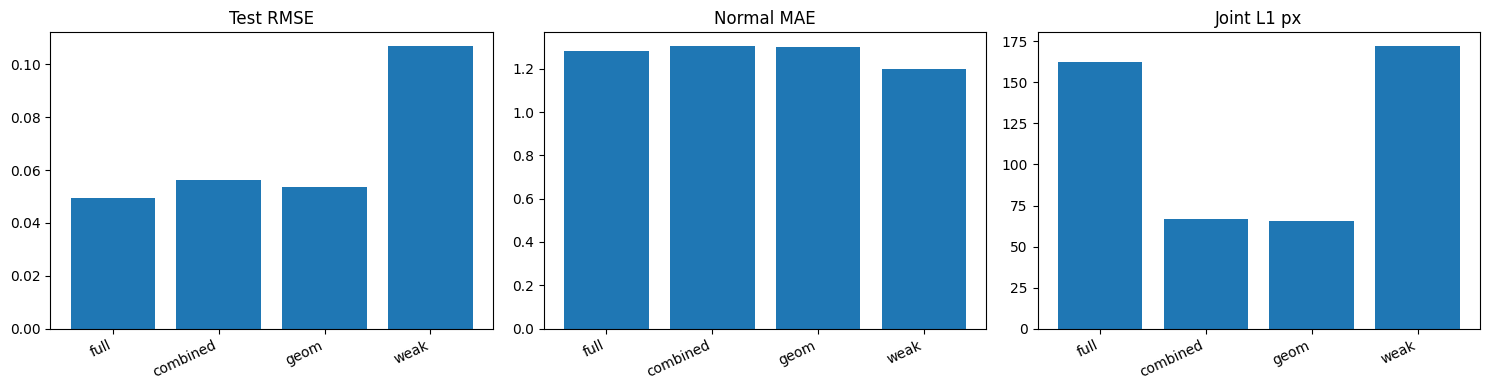

In [14]:
df = pd.DataFrame(results)
cols = ['label', 'regime', 'status', 'val_rmse', 'test_rmse', 'normal_mae', 'joint_l1_px', 'fps', 'params', 'gpu_mb', 'patch_size', 'batch_size', 'lr', 'checkpoint', 'history_path', 'result_path']
for col in cols:
    if col not in df.columns:
        df[col] = None
df = df[cols].sort_values(['status', 'val_rmse']).reset_index(drop=True)
summary_path = RUNS_ROOT / 'd3_results.csv'
df.to_csv(summary_path, index=False)
print(f'Saved: {summary_path}')
print(df.to_string(index=False))

plot_df = df[df['status'] == 'ok']
if len(plot_df):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    x = np.arange(len(plot_df))
    for ax, col, title in zip(axes, ['test_rmse', 'normal_mae', 'joint_l1_px'], ['Test RMSE', 'Normal MAE', 'Joint L1 px']):
        ax.bar(x, plot_df[col])
        ax.set_title(title)
        ax.set_xticks(x)
        ax.set_xticklabels(plot_df['regime'], rotation=25, ha='right')
    plt.tight_layout()
    plt.savefig(FIG_ROOT / 'd3_results.png', dpi=150)
    plt.show()


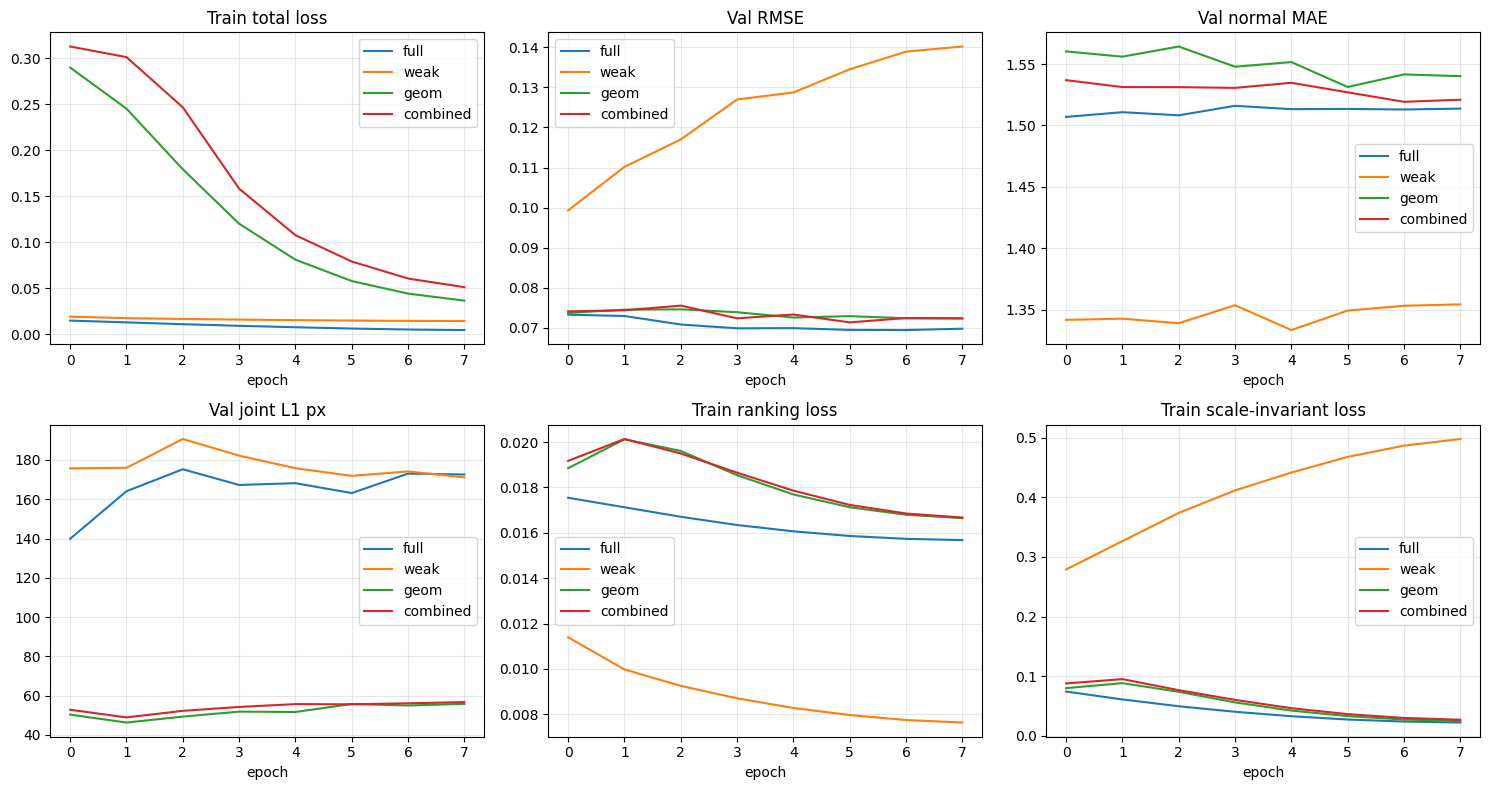

In [15]:
histories = {}
for result in regime_results:
    if result['status'] != 'ok':
        continue
    with open(result['history_path'], 'rb') as fh:
        histories[result['regime']] = pickle.load(fh)

if histories:
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    metrics = [
        ('train_total', 'Train total loss'),
        ('val_rmse', 'Val RMSE'),
        ('val_mae_n', 'Val normal MAE'),
        ('val_joint_l1_px', 'Val joint L1 px'),
        ('train_rank', 'Train ranking loss'),
        ('train_scale_inv', 'Train scale-invariant loss'),
    ]
    for ax, (key, title) in zip(axes.ravel(), metrics):
        for regime, hist in histories.items():
            if key in hist:
                ax.plot(hist[key], label=regime)
        ax.set_title(title)
        ax.set_xlabel('epoch')
        ax.grid(True, alpha=0.3)
        ax.legend()
    plt.tight_layout()
    plt.savefig(FIG_ROOT / 'd3_convergence.png', dpi=150)
    plt.show()


## 11 - Qualitative and Failure-Mode Visuals


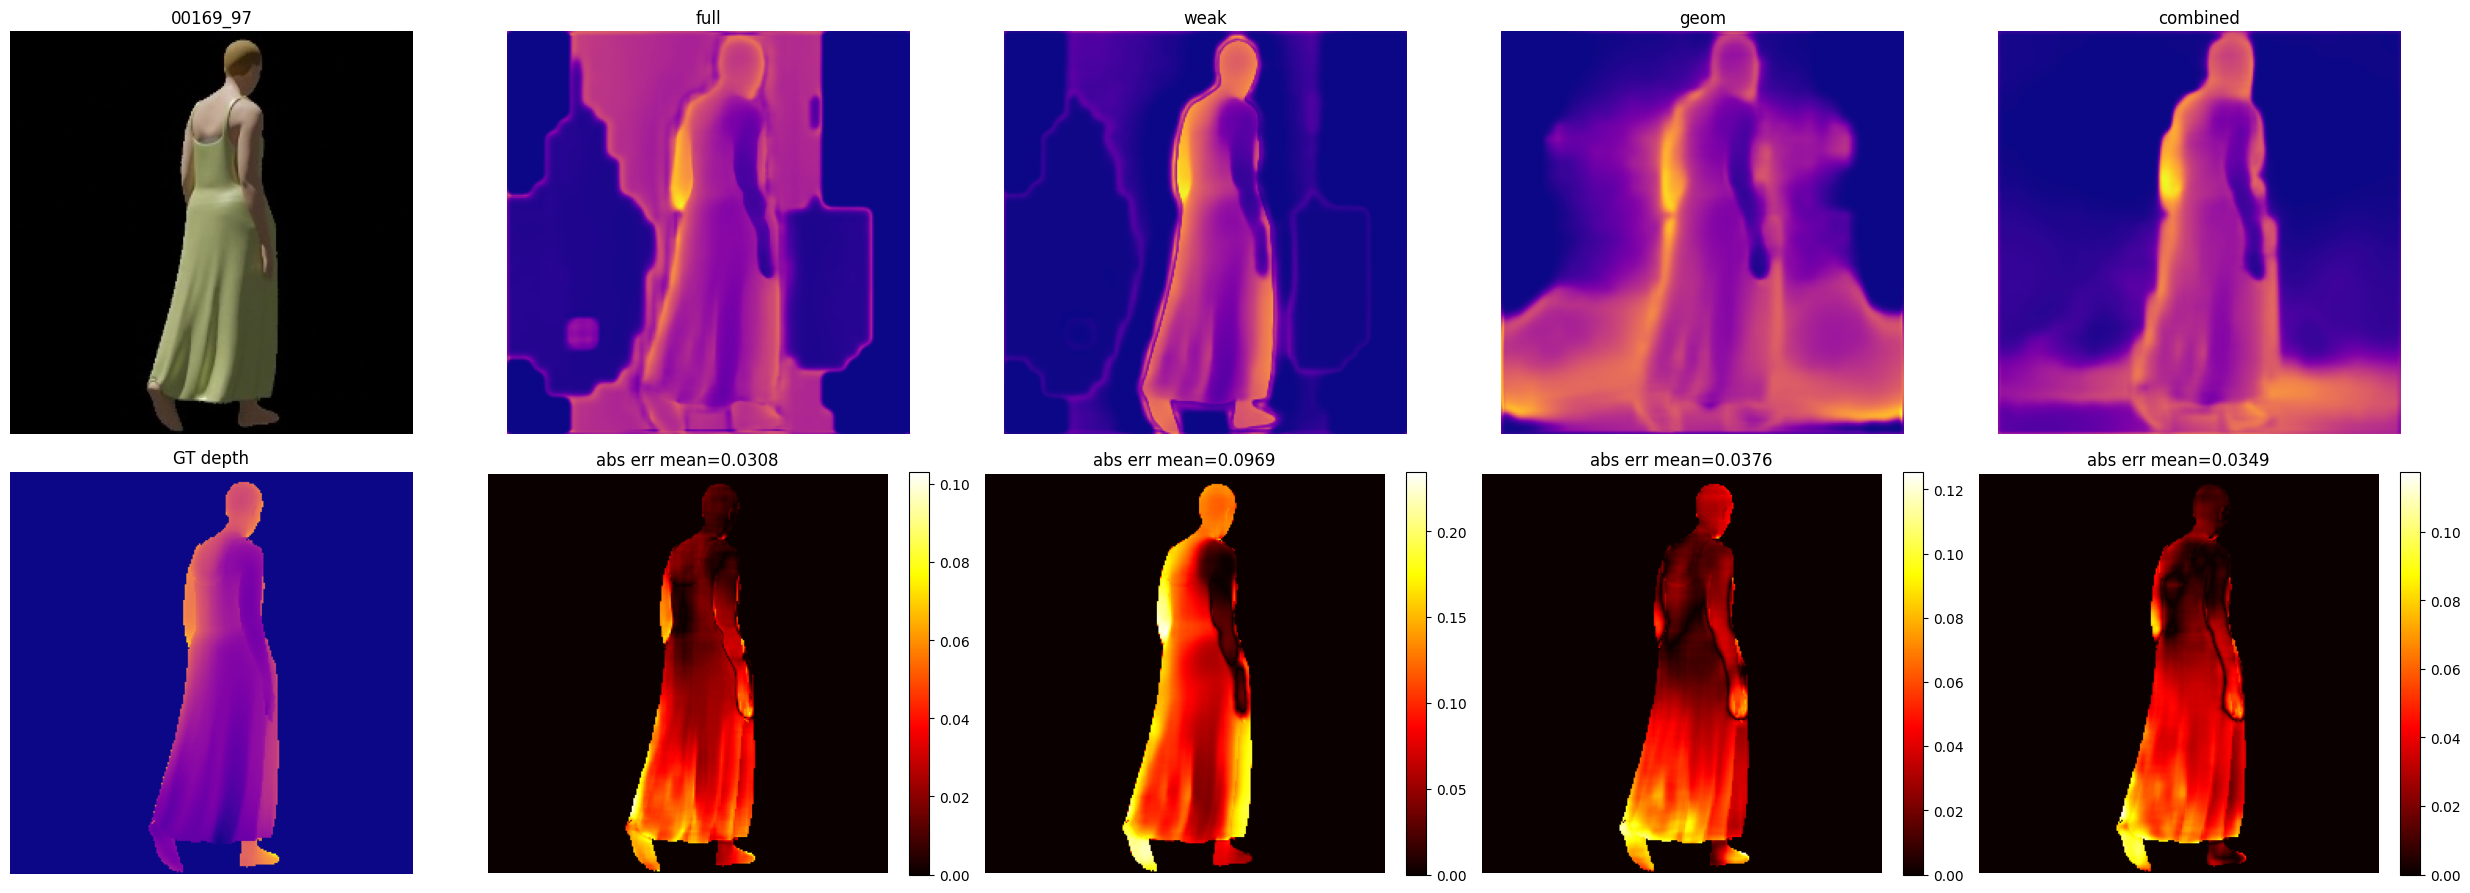

Saved: C:\Users\Daniel Hess\Documents\Master\OR\Pose_Estimation\runs\d3_losses\figures\d3_predictions_sample_0.png


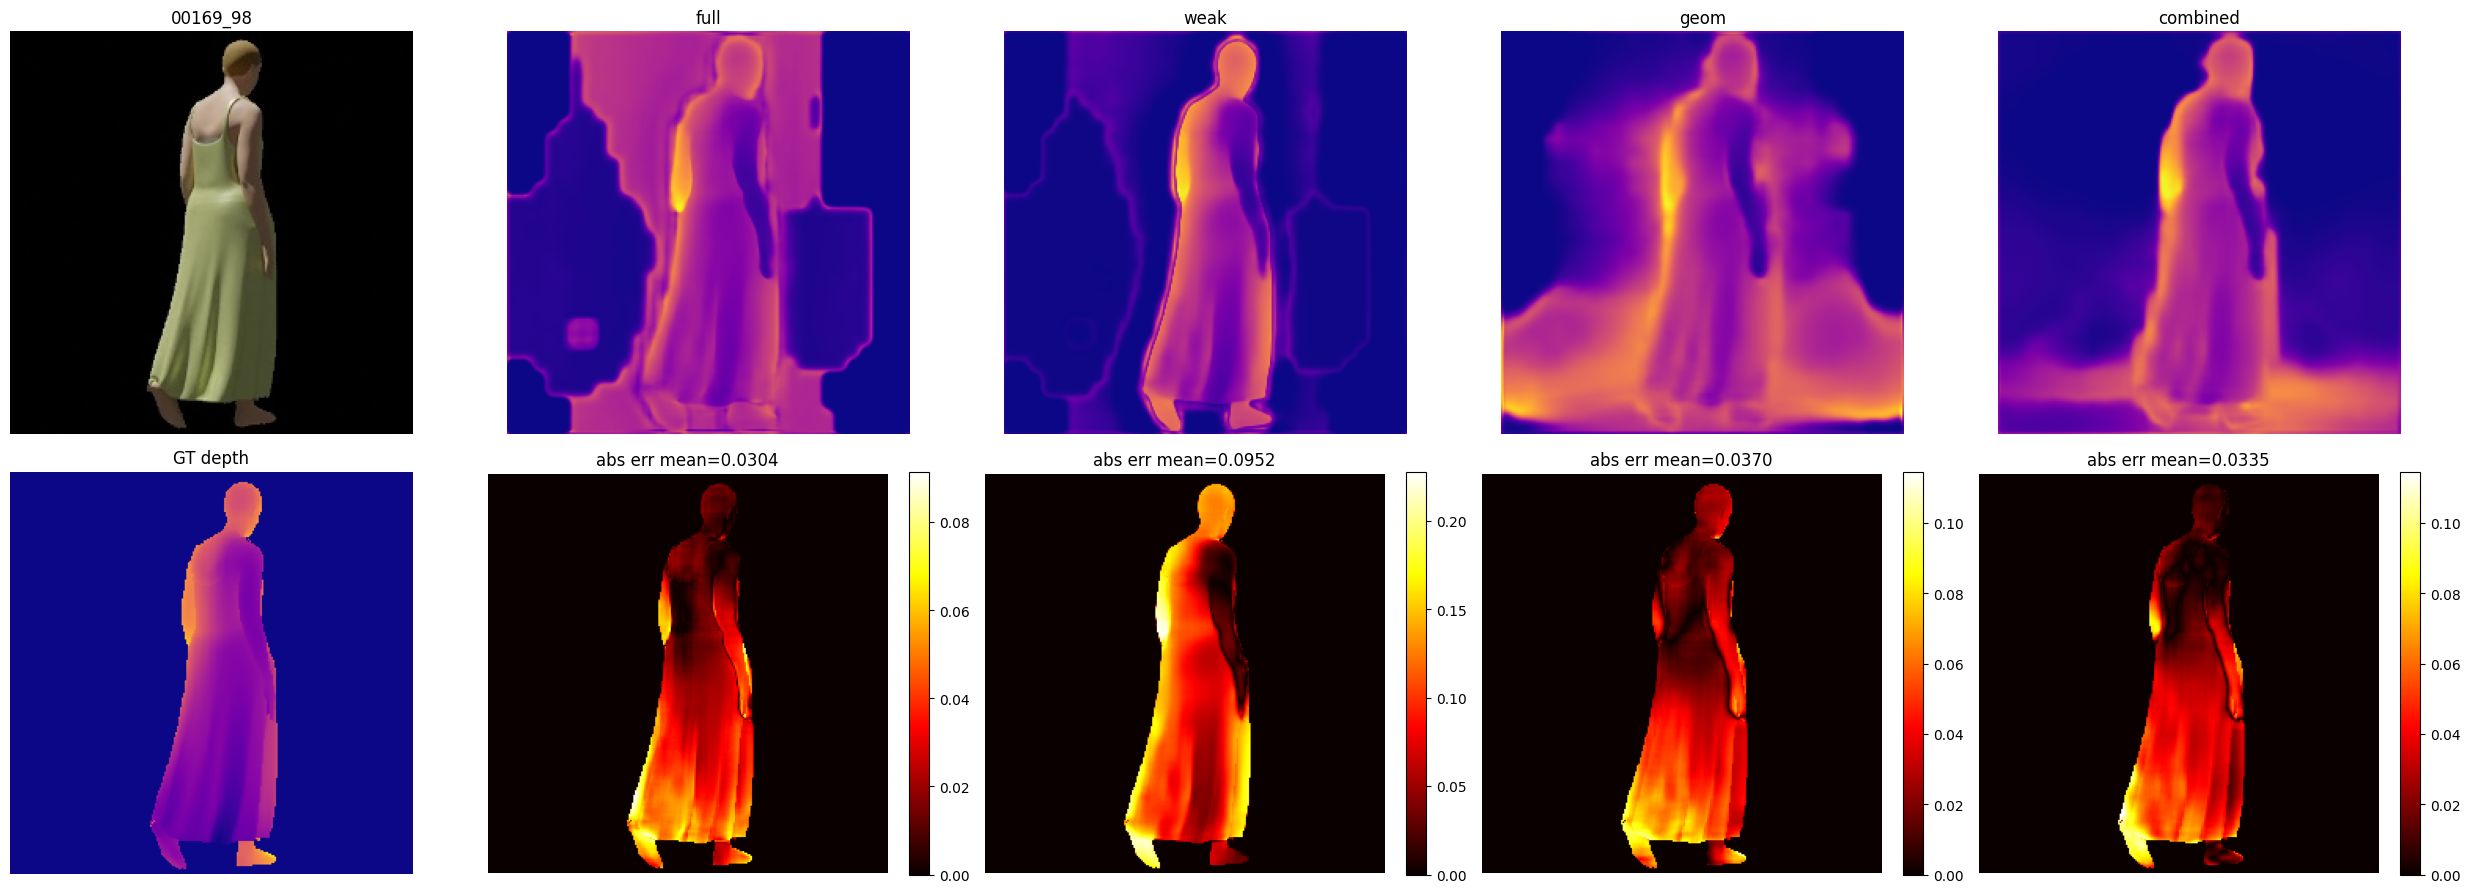

Saved: C:\Users\Daniel Hess\Documents\Master\OR\Pose_Estimation\runs\d3_losses\figures\d3_predictions_sample_1.png


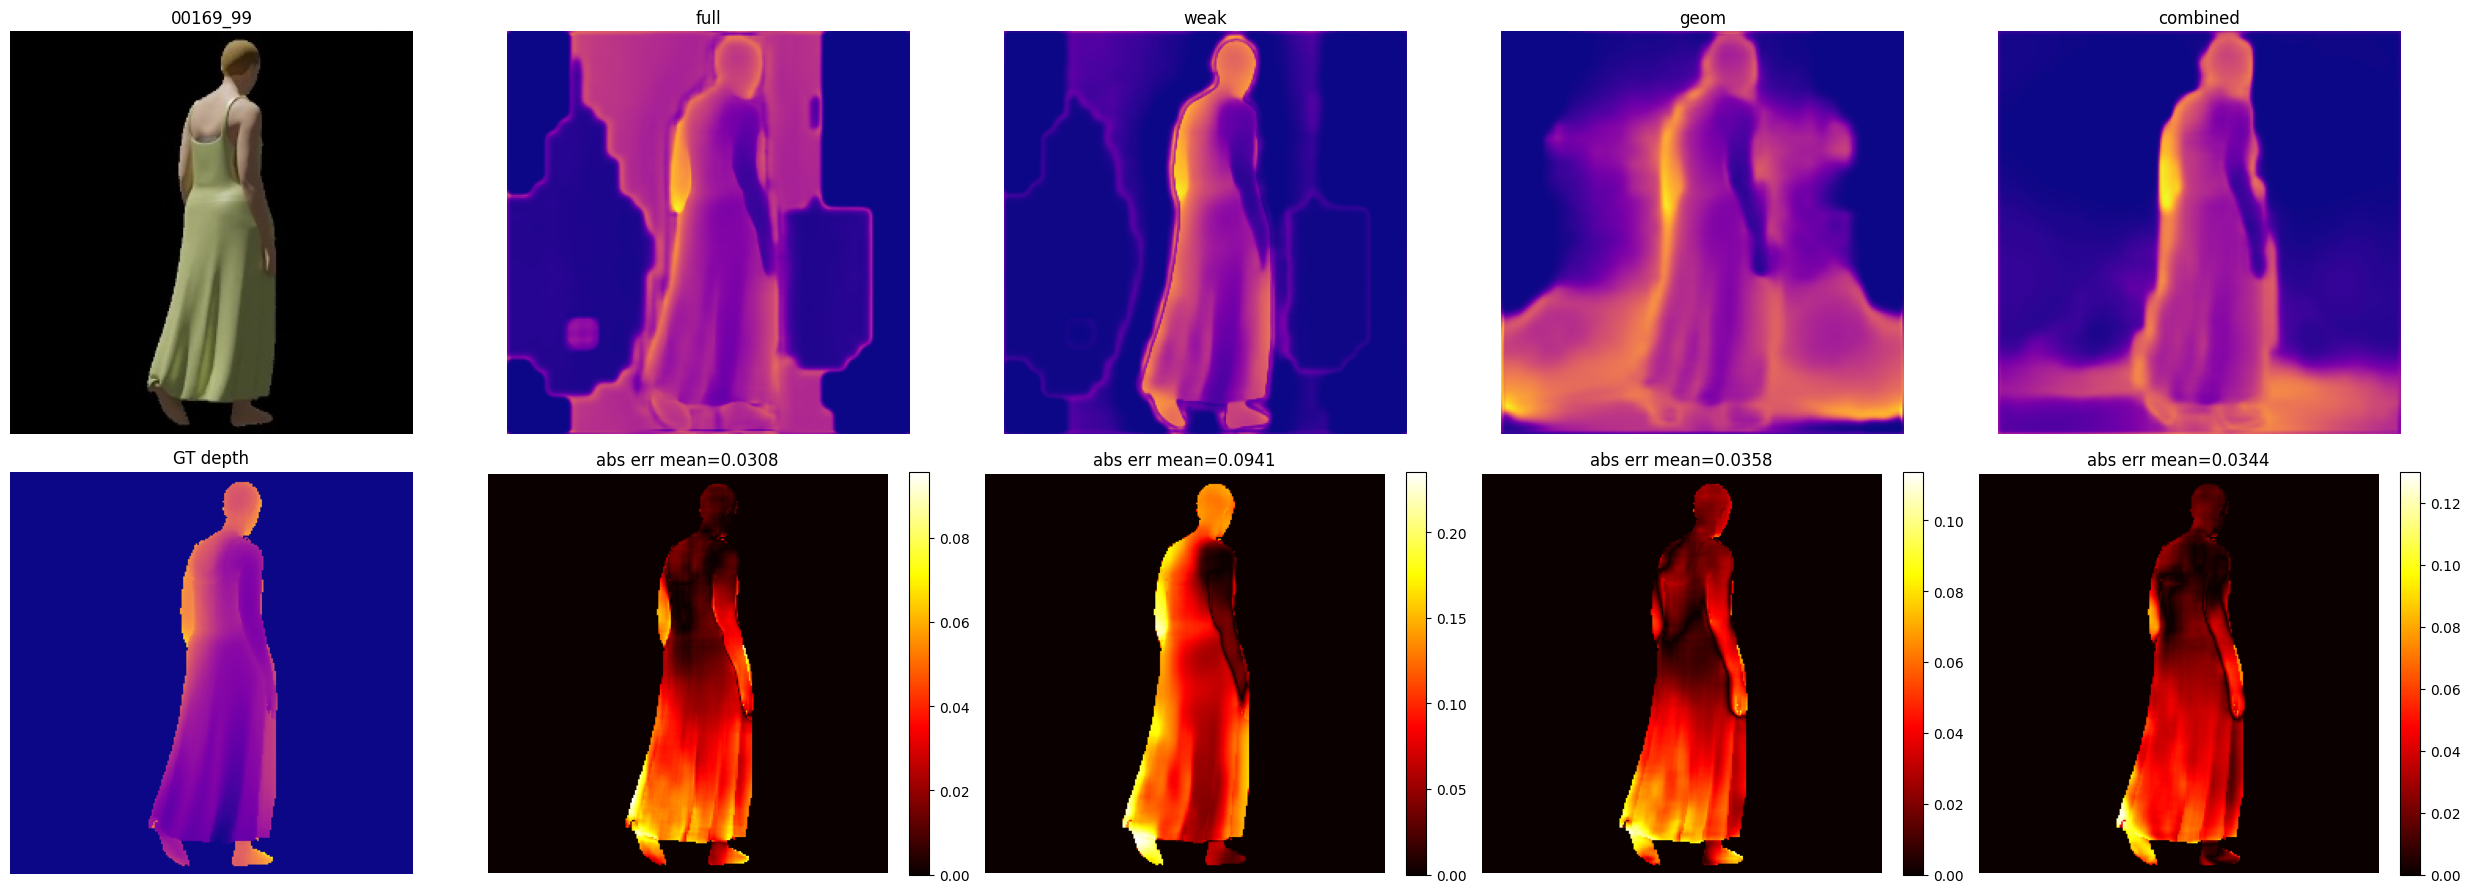

Saved: C:\Users\Daniel Hess\Documents\Master\OR\Pose_Estimation\runs\d3_losses\figures\d3_predictions_sample_2.png


In [16]:
@torch.no_grad()
def visualize_predictions(results_to_show, n_samples=3):
    ds = Cloth3DDatasetD3(test_list, DATA_ROOT, JOINT_CACHE, 256)
    n_samples = min(n_samples, len(ds))
    for sample_idx in range(n_samples):
        X, Y, J, V = ds[sample_idx]
        fig, axes = plt.subplots(2, len(results_to_show) + 1, figsize=(5 * (len(results_to_show) + 1), 9))
        rgb = X.permute(1, 2, 0).numpy()
        rgb = (rgb * IMAGENET_STD + IMAGENET_MEAN).clip(0, 1)
        gt = Y.squeeze().numpy()
        axes[0, 0].imshow(rgb)
        axes[0, 0].set_title(test_list[sample_idx])
        axes[0, 0].axis('off')
        axes[1, 0].imshow(gt, cmap='plasma')
        axes[1, 0].set_title('GT depth')
        axes[1, 0].axis('off')

        for col, result in enumerate(results_to_show, 1):
            cfg = build_cfg(result['regime'])
            model = MultiTaskDepthModel(cfg).to(DEVICE)
            model.load_state_dict(torch.load(result['checkpoint'], map_location=DEVICE, weights_only=True))
            model.eval()
            pred, _ = model(X.unsqueeze(0).to(DEVICE))
            pred_np = pred.cpu().squeeze().numpy()
            err = np.abs(pred_np - gt)
            err[gt <= 0] = 0
            axes[0, col].imshow(pred_np, cmap='plasma')
            axes[0, col].set_title(result['regime'])
            axes[0, col].axis('off')
            im = axes[1, col].imshow(err, cmap='hot')
            axes[1, col].set_title(f'abs err mean={err[gt>0].mean():.4f}')
            axes[1, col].axis('off')
            plt.colorbar(im, ax=axes[1, col], fraction=0.046)
            del model
            cleanup_cuda()
        plt.tight_layout()
        out = FIG_ROOT / f'd3_predictions_sample_{sample_idx}.png'
        plt.savefig(out, dpi=150)
        plt.show()
        print(f'Saved: {out}')


visualize_predictions([r for r in regime_results if r['status'] == 'ok'], n_samples=3)


In [17]:
def texture_map(rgb01):
    gray = cv2.cvtColor((rgb01 * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY).astype(np.float32) / 255.0
    lap = cv2.Laplacian(gray, cv2.CV_32F)
    return cv2.blur(lap ** 2, (5, 5))


@torch.no_grad()
def analyze_failure_modes(results_to_analyze, max_samples=40):
    ds = Cloth3DDatasetD3(test_list, DATA_ROOT, JOINT_CACHE, 256)
    rows = []
    models = {}
    for result in results_to_analyze:
        cfg = build_cfg(result['regime'])
        model = MultiTaskDepthModel(cfg).to(DEVICE)
        model.load_state_dict(torch.load(result['checkpoint'], map_location=DEVICE, weights_only=True))
        model.eval()
        models[result['regime']] = model

    for i in range(min(max_samples, len(ds))):
        X, Y, _, _ = ds[i]
        rgb = X.permute(1, 2, 0).numpy()
        rgb = (rgb * IMAGENET_STD + IMAGENET_MEAN).clip(0, 1)
        tex = texture_map(rgb)
        gt = Y.squeeze().numpy()
        valid = gt > 0
        if not valid.any():
            continue
        tex_valid = tex[valid]
        high_tex = tex >= np.percentile(tex_valid, 75)
        low_tex = tex <= np.percentile(tex_valid, 25)
        edge = cv2.Canny((valid.astype(np.uint8) * 255), 50, 150) > 0
        edge_dil = cv2.dilate(edge.astype(np.uint8), np.ones((5, 5), np.uint8)).astype(bool)
        for regime, model in models.items():
            pred, _ = model(X.unsqueeze(0).to(DEVICE))
            err = np.abs(pred.cpu().squeeze().numpy() - gt)
            rows.append({
                'regime': regime,
                'smooth_error': float(err[valid & low_tex].mean()) if (valid & low_tex).any() else np.nan,
                'textured_error': float(err[valid & high_tex].mean()) if (valid & high_tex).any() else np.nan,
                'edge_error': float(err[valid & edge_dil].mean()) if (valid & edge_dil).any() else np.nan,
                'interior_error': float(err[valid & ~edge_dil].mean()) if (valid & ~edge_dil).any() else np.nan,
            })
    for model in models.values():
        del model
    cleanup_cuda()
    out = pd.DataFrame(rows).groupby('regime').mean(numeric_only=True).reset_index()
    out.to_csv(RUNS_ROOT / 'd3_failure_modes.csv', index=False)
    print(out.to_string(index=False))
    return out


failure_df = analyze_failure_modes([r for r in regime_results if r['status'] == 'ok'], max_samples=40)


  regime  smooth_error  textured_error  edge_error  interior_error
combined      0.023401        0.042482    0.047562        0.029181
    full      0.022263        0.038240    0.043306        0.026020
    geom      0.024033        0.042927    0.045156        0.030960
    weak      0.088246        0.097335    0.108029        0.083742


## 12 - Discussion Notes

### Full supervision vs weak-only vs geometry-aware

Full supervision was the strongest depth objective in the Task 3 comparison. The full L1 depth model reached validation RMSE 0.0695 and test RMSE 0.0494, improving over the Task 2 DeiT baseline. This shows that continuing the best transformer architecture with the direct pixel-wise depth objective was still the most reliable way to improve depth.

Weak-only supervision was not enough for accurate metric depth. The ranking + normal consistency model reached validation RMSE 0.0993 and test RMSE 0.1068, much worse than full supervision. Its normal MAE was relatively competitive at 1.20 deg, but the absolute depth scale and placement were poor because ranking and normals constrain relative ordering and local geometry, not the full depth value at each valid pixel.

The geometry-aware and combined losses improved the auxiliary joint objective, but did not improve depth RMSE in these runs. Geometry-aware training reached validation RMSE 0.0723 and joint L1 65.5 px, while combined training reached validation RMSE 0.0714 and joint L1 66.8 px. Both were better than weak-only and much better at pose localization than the full-depth model, but they were still worse than full supervision for RMSE.

### Failure modes

The failure-mode analysis shows that all models make larger errors around edges than in the interior. For the full model, edge error was about 0.0433 while interior error was about 0.0260. Textured regions were also harder than smooth regions: full supervision had textured error about 0.0382 and smooth error about 0.0223.

This matches the qualitative behavior expected for monocular depth. Cloth texture can look like depth variation even when the surface is nearly flat, while silhouettes and garment boundaries require very precise alignment. Weak-only supervision amplified these problems, with much larger edge and interior errors.

### Stability vs accuracy

The full depth L1 run was the most stable and accurate for the main depth metric. Weak-only training was less stable as a depth estimator because the losses did not anchor absolute scale. Geometry-aware and combined runs added useful structure for joint localization, but the extra objectives competed with pure RMSE optimization.

One important implementation note: after inspecting the joint cache visualization, the SMPL joint projection was corrected to regress joints from posed vertices and cache them with version `posed_vertex_regressed_v2`. Therefore, geometry-aware conclusions should be interpreted together with the corrected Task 4 rerun, which uses the fixed joint cache more directly for final integration.

### Loss convergence and overfitting

Pixel-wise L1 converged fastest toward low RMSE because it directly optimizes the target depth values used by the evaluation. Ranking and normal losses are useful geometric regularizers, but by themselves they are underconstrained. Scale-invariant and joint losses can help encode body structure, but their weights must be small; otherwise, they can improve auxiliary behavior while slightly hurting the primary depth metric.